In [44]:
import numpy as np
import gzip
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm

import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

In [45]:
def load_mnist_dataset(mnist_path):
    x_trainval = get_images(Path(mnist_path)/Path('train-images-idx3-ubyte.gz'))
    y_trainval = get_labels(Path(mnist_path)/Path('train-labels-idx1-ubyte.gz'))

    x_train = x_trainval[:50000]
    y_train = y_trainval[:50000]

    x_val = x_trainval[50000:]
    y_val = y_trainval[50000:]

    x_test = get_images(Path(mnist_path)/Path('t10k-images-idx3-ubyte.gz'))
    y_test = get_labels(Path(mnist_path)/Path('t10k-labels-idx1-ubyte.gz'))

    return x_train, y_train, x_val, y_val, x_test, y_test

def get_labels(path):
    with gzip.open(path, 'rb') as data:
        labels = data.read()[8:]
        return np.frombuffer(labels, dtype=np.uint8)

def get_images(path):
    with gzip.open(path, 'rb') as data:
        _ = int.from_bytes(data.read(4), 'big')
        num_images = int.from_bytes(data.read(4), 'big')
        rows = int.from_bytes(data.read(4), 'big')
        cols = int.from_bytes(data.read(4), 'big')
        images = data.read()
        return np.frombuffer(images, dtype=np.uint8).reshape((num_images, rows, cols))

In [46]:
x_train, y_train, x_val, y_val, x_test, y_test = load_mnist_dataset('data/MNIST/raw')

In [47]:
x_train = x_train.copy().reshape(50000, -1).astype(np.float32)
y_train = y_train.copy().reshape(50000, 1)

x_val = x_val.copy().reshape(10000, -1).astype(np.float32)
y_val = y_val.copy().reshape(10000, 1)

x_test = x_test.copy().reshape(10000, -1).astype(np.float32)
y_test = y_test.copy().reshape(10000, 1)

In [48]:
def plot_number(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.reshape((28,28)), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

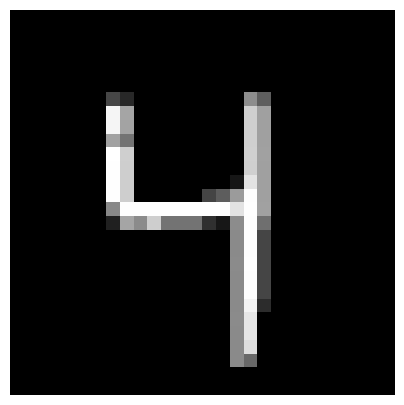

'Label: 4'

In [49]:
random_idx = np.random.randint(0, x_train.shape[0])
plot_number(x_train[random_idx])
display(f"Label: {y_train[random_idx].squeeze()}")

Aqui se carga el dataset MNIST usando PyTorch. También se aplica una transformación para convertir las imágenes a tensores y normalizarlas.

In [50]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset_full = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_dataset, val_dataset = random_split(train_dataset_full, [50000, 10000])

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128)
test_loader = DataLoader(test_dataset, batch_size=128)

In [51]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

Esta función evalua el modelo calculando la perdida y el accuracy sobre un conjunto de datos (validación o test).

In [52]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            outputs = model(x)
            loss = criterion(outputs, y)

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss / len(loader), correct / total

Esta clase implementa early stopping, detiene el entrenamiento si la perdida de validación deja de mejorar después de 3 epocas

In [53]:
class EarlyStopping:
    def __init__(self, patience=3, delta=0.005):
        self.patience = patience
        self.delta = delta
        self.history = []

    def check(self, val_loss):
        self.history.append(val_loss)

        if len(self.history) > self.patience:
            old_loss = self.history[-(self.patience+1)]
            new_loss = self.history[-1]

            if abs(old_loss - new_loss) < self.delta and old_loss <= new_loss:
                return True 

        return False

Se implementa el proceso de entrenamiento, se recorre el dataset en mini-batches, se calcula la perdida, se hace backpropagation y se actualizan los pesos. Al final de cada época se evalúa el modelo en validación.

In [54]:
def train(model, train_loader, val_loader, epochs, lr):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    early_stopper = EarlyStopping(patience=3, delta=0.005)

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for x, y in train_loader:
            optimizer.zero_grad()

            outputs = model(x)
            loss = criterion(outputs, y)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        val_loss, val_acc = evaluate(model, val_loader, criterion)

        print(f"Epoch {epoch+1}: Train Loss={running_loss/len(train_loader):.4f} | Val Loss={val_loss:.4f} | Val Acc={val_acc:.4f}")

        if early_stopper.check(val_loss):
            print("Early stop")
            break

In [55]:
# Modelo 1
model1 = MLP()
train(model1, train_loader, val_loader, epochs=15, lr=0.001)

# Modelo 2 (learning rate diferente)
model2 = MLP()
train(model2, train_loader, val_loader, epochs=15, lr=0.0005)

# Modelo 3 (batch size diferente)
train_loader_small = DataLoader(train_dataset, batch_size=64, shuffle=True)
model3 = MLP()
train(model3, train_loader_small, val_loader, epochs=15, lr=0.001)

Epoch 1: Train Loss=0.4320 | Val Loss=0.2469 | Val Acc=0.9284
Epoch 2: Train Loss=0.1973 | Val Loss=0.1659 | Val Acc=0.9484
Epoch 3: Train Loss=0.1397 | Val Loss=0.1254 | Val Acc=0.9600
Epoch 4: Train Loss=0.1095 | Val Loss=0.1317 | Val Acc=0.9572
Epoch 5: Train Loss=0.0898 | Val Loss=0.1119 | Val Acc=0.9620
Epoch 6: Train Loss=0.0728 | Val Loss=0.0844 | Val Acc=0.9734
Epoch 7: Train Loss=0.0647 | Val Loss=0.0866 | Val Acc=0.9728
Epoch 8: Train Loss=0.0567 | Val Loss=0.0922 | Val Acc=0.9695
Epoch 9: Train Loss=0.0485 | Val Loss=0.0903 | Val Acc=0.9725
Epoch 10: Train Loss=0.0439 | Val Loss=0.0803 | Val Acc=0.9763
Epoch 11: Train Loss=0.0401 | Val Loss=0.0906 | Val Acc=0.9726
Epoch 12: Train Loss=0.0380 | Val Loss=0.0869 | Val Acc=0.9748
Epoch 13: Train Loss=0.0319 | Val Loss=0.0991 | Val Acc=0.9712
Epoch 14: Train Loss=0.0303 | Val Loss=0.0817 | Val Acc=0.9765
Epoch 15: Train Loss=0.0266 | Val Loss=0.0936 | Val Acc=0.9746
Epoch 1: Train Loss=0.5007 | Val Loss=0.2925 | Val Acc=0.9111
Ep

In [56]:
criterion = nn.CrossEntropyLoss()

test_loss, test_acc = evaluate(model1, test_loader, criterion)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.0967
Test Accuracy: 0.9749


In [57]:
test_loss, test_acc = evaluate(model2, test_loader, criterion)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.0895
Test Accuracy: 0.9718


In [58]:
test_loss, test_acc = evaluate(model3, test_loader, criterion)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.0957
Test Accuracy: 0.9736


Durante esta actividad aprendí cómo implementar una red neuronal tipo MLP en PyTorch, incluyendo el uso de mini batches, funciones de loss y optimizadores. Uno de los aspectos más importantes fue entender como cambios en hiperparametros como el learning rate o el tamaño del batch afectan el rendimiento del modelo. También implemente early stopping, lo cual permite evitar overfitting al detener el entrenamiento cuando el modelo deja de mejorar en validación. En general, esta práctica me ayudó a entender mejor el flujo completo del entrenamiento de redes neuronales.